In [33]:
!pip install findspark

In [34]:
import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("BigData9") \
    .getOrCreate()

data = [
    ('James', 34, 'M', 3000, 1),
    ('Anna', 28, 'F', 4100, 2),
    ('Lee', 23, 'M', 2700, 1)
]
columns = ['Name', 'Age', 'Gender', 'Salary', 'DeptId']
df = spark.createDataFrame(data, schema=columns)
df.createOrReplaceTempView('employees')
spark.sql('SELECT * FROM employees').show()
spark.sql('SELECT Name, Age FROM employees WHERE Salary > 3000').show()
spark.sql('SELECT AVG(Salary) FROM employees').show()

ConnectionRefusedError: [Errno 111] Connection refused

In [4]:
spark.sql('''
SELECT Gender, SUM(Salary) as TotalSalary, Age
FROM employees
GROUP BY Gender, Age
ORDER BY Age
''').show()

+------+-----------+---+
|Gender|TotalSalary|Age|
+------+-----------+---+
|     M|       2700| 23|
|     F|       4100| 28|
|     M|       3000| 34|
+------+-----------+---+



In [3]:
spark.sql('''
SELECT Name, Age, Salary, ROW_NUMBER() OVER (PARTITION BY Age ORDER BY Salary DESC) as rank
FROM employees
''').show()

+-----+---+------+----+
| Name|Age|Salary|rank|
+-----+---+------+----+
|  Lee| 23|  2700|   1|
| Anna| 28|  4100|   1|
|James| 34|  3000|   1|
+-----+---+------+----+



In [7]:
employees = spark.createDataFrame([
    ('James', 34, 'M', 3000, 1),
    ('Anna', 28, 'F', 4100, 2),
    ('Lee', 23, 'M', 2700, 1)
], ['Name', 'Age', 'Gender', 'Salary', 'DeptId'])
departments = spark.createDataFrame([
    (1, 'HR'),
    (2, 'Marketing')
], ['DeptId', 'DeptName'])
projects = spark.createDataFrame([
    (1, 'Project A'),
    (2, 'Project B')
], ['DeptId', 'ProjectName'])
employees.createOrReplaceTempView('employees')
departments.createOrReplaceTempView('departments')
projects.createOrReplaceTempView('projects')

spark.sql('''
SELECT e.Name, e.Age, d.DeptName, p.ProjectName
FROM employees e
JOIN departments d ON e.DeptId = d.DeptId
JOIN projects p ON e.DeptId = p.DeptId
''').show()

+-----+---+---------+-----------+
| Name|Age| DeptName|ProjectName|
+-----+---+---------+-----------+
|  Lee| 23|       HR|  Project A|
|James| 34|       HR|  Project A|
| Anna| 28|Marketing|  Project B|
+-----+---+---------+-----------+



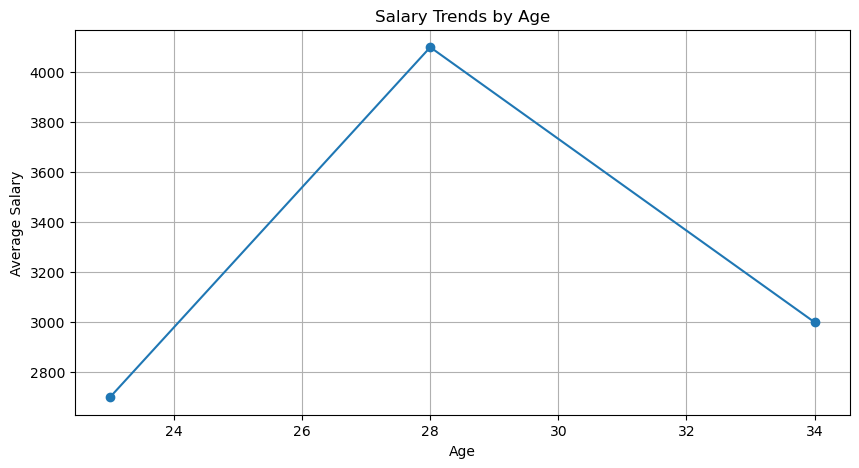

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

salary_trends = spark.sql('''
SELECT Age, AVG(Salary) AS AverageSalary
FROM employees
GROUP BY Age
ORDER BY Age
''').toPandas()

plt.figure(figsize=(10, 5))
plt.plot(salary_trends['Age'], salary_trends['AverageSalary'], marker='o')
plt.xlabel('Age')
plt.ylabel('Average Salary')
plt.title('Salary Trends by Age')
plt.grid(True)
plt.show()

+------+-----------+--------------+
|DeptId|TotalSalary|TotalEmployees|
+------+-----------+--------------+
|     1|       5700|             2|
|     2|       4100|             1|
+------+-----------+--------------+



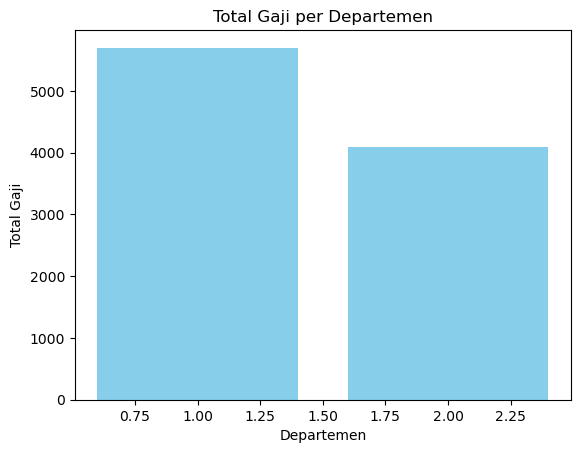

In [21]:
kode = spark.sql('''
SELECT DeptId,
SUM(Salary) AS TotalSalary,
COUNT(Name) AS TotalEmployees
FROM employees
GROUP BY DeptId
''')
kode.show()

pandas_df = kode.toPandas()

plt.bar(pandas_df["DeptId"], pandas_df["TotalSalary"], color='skyblue')
plt.xlabel("Departemen")
plt.ylabel("Total Gaji")
plt.title("Total Gaji per Departemen")
plt.show()

+----+-----------+------+----------------+
|Name|   AgeGroup|Salary|avg_group_salary|
+----+-----------+------+----------------+
|Anna|Dewasa Muda|  4100|          3550.0|
+----+-----------+------+----------------+



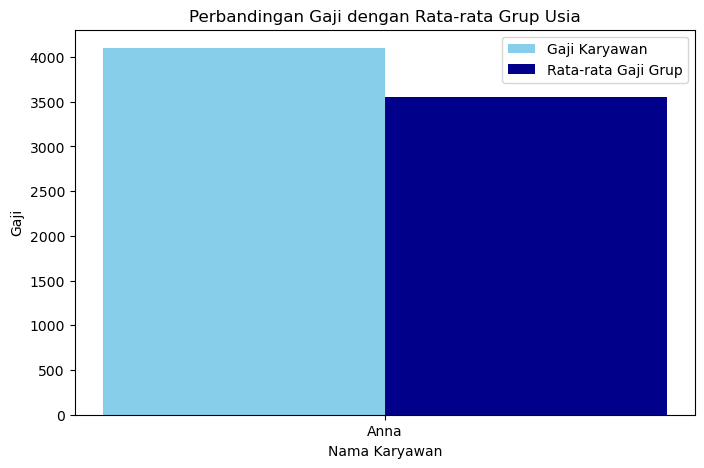

In [29]:
df_tugas6_2 = spark.sql("""
WITH EmployeeAgeGroups AS (SELECT *, CASE
WHEN Age < 25 THEN 'Muda'
WHEN Age >= 25 AND Age <= 35 THEN 'Dewasa Awal'
ELSE 'Dewasa'
END AS AgeGroup
FROM employees
),
AvgSalaryByAgeGroup AS (
SELECT *, AVG(Salary) OVER (PARTITION BY AgeGroup) as avg_salary_for_age_group
FROM EmployeeAgeGroups
)
SELECT Name, AgeGroup, Salary, 
ROUND(avg_salary_for_age_group, 2) AS avg_group_salary
FROM AvgSalaryByAgeGroup
WHERE Salary > avg_salary_for_age_group
""")
df_tugas6_2.show()

df_pd = df_tugas6_2.toPandas()

labels = df_pd['Name']
salary = df_pd['Salary']
avg_salary = df_pd['avg_group_salary']

x = pd.Series(range(len(labels))) 
plt.figure(figsize=(8, 5))
plt.bar(x - 0.2, salary, width=0.4, label='Gaji Karyawan', color='skyblue')
plt.bar(x + 0.2, avg_salary, width=0.4, label='Rata-rata Gaji Grup', color='darkblue')
plt.xlabel('Nama Karyawan')
plt.ylabel('Gaji')
plt.title('Perbandingan Gaji dengan Rata-rata Grup Usia')
plt.xticks(x, labels)  
plt.legend()
plt.show()

Tabel Departments
+------+-----------+--------+
|DeptId|   DeptName|Location|
+------+-----------+--------+
|     1|Engineering| Jakarta|
|     2|      Sales|Surabaya|
|     3|  Marketing| Jakarta|
|     4|         HR| Bandung|
|     5|    Finance|Surabaya|
+------+-----------+--------+

Tabel Employees_Large
+-----+-----+---+------+------+------+
|EmpId| Name|Age|Gender|Salary|DeptId|
+-----+-----+---+------+------+------+
|    1|  Adi| 28|     M|  7500|     1|
|    2| Budi| 32|     M|  8200|     2|
|    3|Citra| 25|     F|  6800|     1|
|    4| Dewi| 40|     F|  9100|     3|
|    5|  Eka| 27|     M|  7200|     2|
+-----+-----+---+------+------+------+
only showing top 5 rows

Analisis JOIN
+-----------+--------+-------------+-------------+-----------+
|   DeptName|Location|EmployeeCount|AverageSalary|TotalSalary|
+-----------+--------+-------------+-------------+-----------+
|         HR| Bandung|           17|      9129.41|     155200|
|    Finance|Surabaya|           13|      8746.

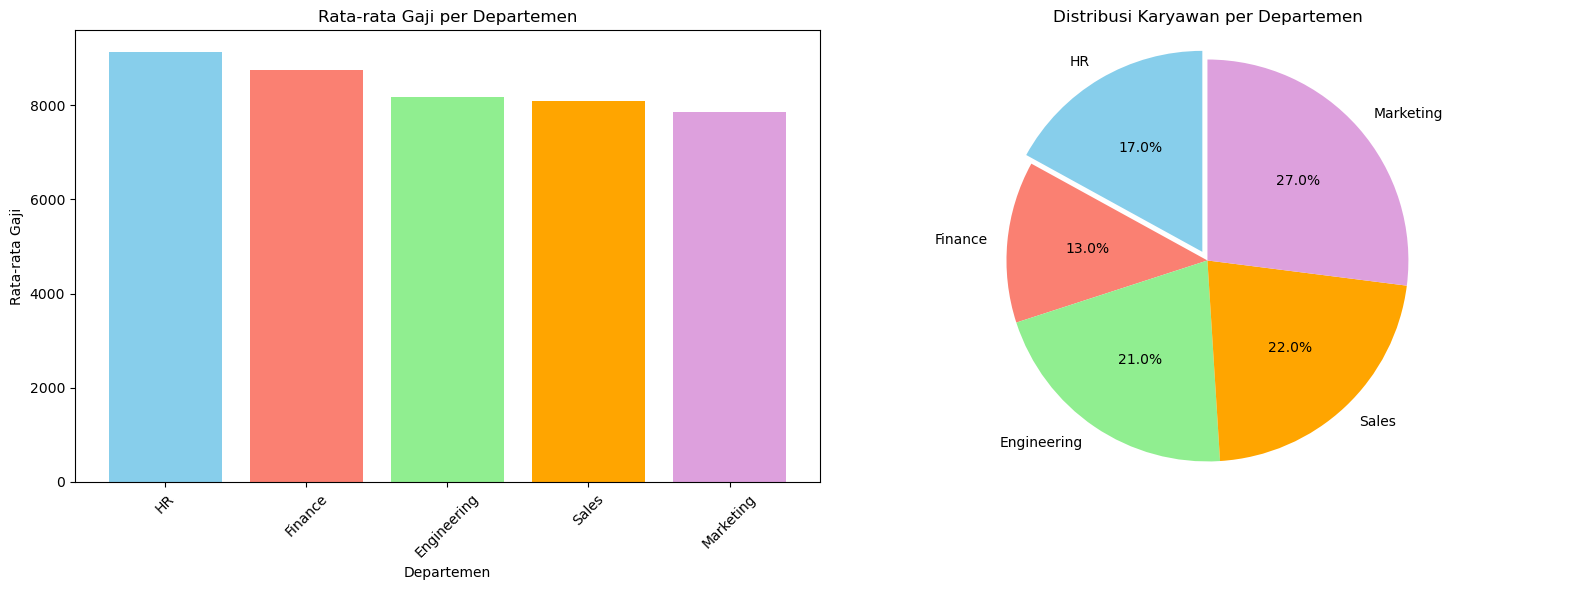

In [7]:
import findspark
findspark.init()
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import pandas as pd

# SparkSession
spark = SparkSession.builder \
    .appName("Tugas3_AnalisisData") \
    .getOrCreate()

dept_data = [
    (1, 'Engineering', 'Jakarta'),
    (2, 'Sales', 'Surabaya'),
    (3, 'Marketing', 'Jakarta'),
    (4, 'HR', 'Bandung'),
    (5, 'Finance', 'Surabaya')
]
dept_columns = ['DeptId', 'DeptName', 'Location']

df_departments = spark.createDataFrame(dept_data, schema=dept_columns)
df_departments.createOrReplaceTempView('departments')

print("Tabel Departments")
df_departments.show()

# pake list of tuple
employee_data = [
    (1,'Adi',28,'M',7500,1),
    (2,'Budi',32,'M',8200,2),
    (3,'Citra',25,'F',6800,1),
    (4,'Dewi',40,'F',9100,3),
    (5,'Eka',27,'M',7200,2),
    (6,'Fajar',35,'M',8800,4),
    (7,'Gita',29,'F',9400,3),
    (8,'Hadi',31,'M',8500,1),
    (9,'Indah',26,'F',7100,2),
    (10,'Joko',33,'M',9900,5),
    (11,'Lina',45,'F',10500,4),
    (12,'Mira',23,'F',6700,3),
    (13,'Niko',37,'M',8800,1),
    (14,'Oka',30,'M',8900,5),
    (15,'Putri',41,'F',9600,2),
    (16,'Rizal',34,'M',9200,3),
    (17,'Sari',25,'F',6800,1),
    (18,'Tono',39,'M',10000,4),
    (19,'Umar',29,'M',8400,2),
    (20,'Vina',28,'F',7300,5),
    (21,'Wulan',35,'F',8700,3),
    (22,'Yanto',30,'M',7800,1),
    (23,'Zahra',27,'F',7600,4),
    (24,'Agus',42,'M',9700,2),
    (25,'Bella',26,'F',7200,3),
    (26,'Chandra',29,'M',8100,5),
    (27,'Dian',24,'F',6900,1),
    (28,'Edo',31,'M',8600,2),
    (29,'Fani',25,'F',7400,3),
    (30,'Gilang',33,'M',9000,4),
    (31,'Hendra',38,'M',8800,5),
    (32,'Intan',27,'F',7500,3),
    (33,'Jefri',36,'M',8900,1),
    (34,'Kiki',29,'F',8200,2),
    (35,'Lucky',30,'M',9300,4),
    (36,'Mona',25,'F',7100,3),
    (37,'Nanda',34,'M',8500,1),
    (38,'Ovi',28,'F',7700,2),
    (39,'Pandu',40,'M',10200,4),
    (40,'Qori',23,'F',6600,3),
    (41,'Rio',31,'M',8600,1),
    (42,'Sinta',29,'F',8000,5),
    (43,'Tegar',26,'M',7200,2),
    (44,'Uli',33,'F',8800,3),
    (45,'Vito',35,'M',9700,4),
    (46,'Widya',30,'F',8300,2),
    (47,'Xavier',37,'M',9100,1),
    (48,'Yuni',28,'F',7400,3),
    (49,'Zaki',39,'M',9500,4),
    (50,'Andre',32,'M',8700,5),
    (51,'Bella',26,'F',7100,3),
    (52,'Cahyo',29,'M',8200,1),
    (53,'Dinda',27,'F',7500,2),
    (54,'Eris',36,'M',9100,4),
    (55,'Felix',40,'M',9800,5),
    (56,'Gina',23,'F',6700,3),
    (57,'Harry',31,'M',8900,2),
    (58,'Irma',30,'F',7600,1),
    (59,'Jaya',28,'M',8700,4),
    (60,'Karen',33,'F',9100,3),
    (61,'Lutfi',34,'M',9300,1),
    (62,'Maya',25,'F',7000,2),
    (63,'Nur',26,'F',7200,3),
    (64,'Oscar',29,'M',8600,5),
    (65,'Poppy',28,'F',7400,4),
    (66,'Qomar',35,'M',9500,2),
    (67,'Rani',27,'F',7700,3),
    (68,'Seno',31,'M',8800,1),
    (69,'Tari',30,'F',7900,5),
    (70,'Utami',24,'F',6800,3),
    (71,'Vincent',32,'M',9100,2),
    (72,'Wahyu',33,'M',9200,4),
    (73,'Xena',28,'F',7500,3),
    (74,'Yoga',29,'M',8600,1),
    (75,'Zara',25,'F',7100,2),
    (76,'Andi',34,'M',8800,5),
    (77,'Bayu',38,'M',9700,4),
    (78,'Cindy',27,'F',7400,3),
    (79,'Darma',31,'M',8900,1),
    (80,'Eva',29,'F',8200,2),
    (81,'Ferdi',36,'M',9100,3),
    (82,'Ghea',25,'F',7000,1),
    (83,'Hafidz',40,'M',10100,4),
    (84,'Intan',30,'F',8300,3),
    (85,'Joni',28,'M',7800,2),
    (86,'Karin',27,'F',7600,3),
    (87,'Lukman',35,'M',9000,1),
    (88,'Mila',24,'F',6700,2),
    (89,'Nando',33,'M',8800,4),
    (90,'Olia',29,'F',7400,3),
    (91,'Pras',31,'M',8900,5),
    (92,'Queen',25,'F',7100,2),
    (93,'Rama',37,'M',9600,3),
    (94,'Susi',26,'F',7300,1),
    (95,'Taufik',34,'M',8700,2),
    (96,'Uni',28,'F',7800,3),
    (97,'Via',27,'F',7600,4),
    (98,'Wawan',40,'M',10000,5),
    (99,'Xeni',29,'F',7900,3),
    (100,'Yogi',31,'M',8800,1)
]

# Schema kolom
emp_columns = ['EmpId', 'Name', 'Age', 'Gender', 'Salary', 'DeptId']

#  Bikin DataFrame
df_employees_large = spark.createDataFrame(employee_data, schema=emp_columns)
df_employees_large.createOrReplaceTempView('employees_large')

print("Tabel Employees_Large")
df_employees_large.show(5) 


print("Analisis JOIN")

df_analisis = spark.sql("""
SELECT 
d.DeptName,
d.Location,
COUNT(e.EmpId) AS EmployeeCount,
ROUND(AVG(e.Salary), 2) AS AverageSalary,
SUM(e.Salary) AS TotalSalary
FROM employees_large e 
JOIN departments d 
ON e.DeptId = d.DeptId
GROUP BY 
d.DeptName, d.Location
ORDER BY 
AverageSalary DESC
""")

df_analisis.show()

print("Visualisasi")

# Mengubah data Spark ke Pandas buat di-plot
df_analisis_pd = df_analisis.toPandas()

# Membuat 2 plot (1 baris, 2 kolom)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar Chart Rata-rata Gaji

colors = ['skyblue', 'salmon', 'lightgreen', 'orange', 'plum']
ax1.bar(df_analisis_pd['DeptName'], df_analisis_pd['AverageSalary'], color=colors)
ax1.set_title('Rata-rata Gaji per Departemen')
ax1.set_xlabel('Departemen')
ax1.set_ylabel('Rata-rata Gaji')
ax1.tick_params(axis='x', rotation=45) 

# Pie Chart Distribusi Karyawan 
ax2.pie(df_analisis_pd['EmployeeCount'], labels=df_analisis_pd['DeptName'], autopct='%1.1f%%',
colors=colors, startangle=90, explode=(0.05, 0, 0, 0, 0)) 
ax2.set_title('Distribusi Karyawan per Departemen')
ax2.axis('equal')  

plt.tight_layout()
plt.show()

In [ ]:
# TUGAS TUGAS

In [21]:
# TUGAS 2

# RATA RATA SALARY / DEPT
spark.sql('''
SELECT DeptID, ROUND(AVG(Salary), 2) AS average_salary
FROM employees
GROUP BY DeptId
''').show()

#  karyawan yang memiliki gaji di atas rata-rata untuk gender masing-masing
spark.sql('''
SELECT Name, Gender, Salary, avg_salary_gender
FROM (Select *, AVG(Salary) OVER (PARTITION BY Gender) AS avg_salary_gender
FROM employees )
WHERE Salary > avg_salary_gender
''').show()

# ranking karyawan berdasarkan gaji dalam departemen 
spark.sql('''
SELECT Name, DeptId, Salary, Rank() OVER (PARTITION BY DeptId
ORDER BY Salary DESC) AS salary_rank
FROM employees
''').show()

+------+--------------+
|DeptID|average_salary|
+------+--------------+
|     1|        2850.0|
|     2|        4100.0|
+------+--------------+

+-----+------+------+-----------------+
| Name|Gender|Salary|avg_salary_gender|
+-----+------+------+-----------------+
|James|     M|  3000|           2850.0|
+-----+------+------+-----------------+

+-----+------+------+-----------+
| Name|DeptId|Salary|salary_rank|
+-----+------+------+-----------+
|James|     1|  3000|          1|
|  Lee|     1|  2700|          2|
| Anna|     2|  4100|          1|
+-----+------+------+-----------+



In [28]:
# TUGAS 4

# Rata-rata gaji per departemen
spark.sql('''
SELECT DeptId, ROUND(AVG(Salary), 2) AS average_salary
FROM employees
GROUP BY DeptId
''').show()

# Ranking karyawan berdasarkan gaji di dalam departemen
spark.sql('''
SELECT Name, DeptId, Salary, RANK() OVER (PARTITION BY DeptId 
ORDER BY Salary DESC) AS salary_ranking
FROM employees
''').show()

# Tren gaji berdasarkan usia tiap departemen
spark.sql('''
SELECT Name, DeptId, Age, Salary, LAG(Salary, 1, 0) OVER (PARTITION BY DeptId ORDER BY Age) AS salary_younger,
Salary - LAG(Salary, 1, 0) OVER(PARTITION BY DeptId ORDER BY Age) AS salary_by_age
FROM employees
ORDER BY DeptId, Age
''').show()

+------+--------------+
|DeptId|average_salary|
+------+--------------+
|     1|        2850.0|
|     2|        4100.0|
+------+--------------+

+-----+------+------+--------------+
| Name|DeptId|Salary|salary_ranking|
+-----+------+------+--------------+
|James|     1|  3000|             1|
|  Lee|     1|  2700|             2|
| Anna|     2|  4100|             1|
+-----+------+------+--------------+

+-----+------+---+------+--------------+-------------+
| Name|DeptId|Age|Salary|salary_younger|salary_by_age|
+-----+------+---+------+--------------+-------------+
|  Lee|     1| 23|  2700|             0|         2700|
|James|     1| 34|  3000|          2700|          300|
| Anna|     2| 28|  4100|             0|         4100|
+-----+------+---+------+--------------+-------------+

